# Supervised Learning — Parts 5 to 13
## Spam / Phishing Email Detection — CEAS_08 Dataset

## 0. Setup

### 0.1 Imports and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
MAX_TFIDF_FEATURES = 300
NGRAM_RANGE = (1, 2)

DATA_DIR = Path("artifacts")
CLEAN_DATA = DATA_DIR / "ceas08_clean.parquet"

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

### 0.2 Load the cleaned dataset

In [2]:
if not CLEAN_DATA.exists():
    raise FileNotFoundError(
        f"{CLEAN_DATA} not found. Run Final_EDA.ipynb first to generate it."
    )

df = pd.read_parquet(CLEAN_DATA)
print("Shape:", df.shape)
df.head(3)

Shape: (39154, 13)


,sender,receiver,date,subject,body,label,urls,date_parsed,date_suspicious,sender_domain_raw,sender_domain,body_len,subject_len
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,2008-08-05 23:31:02+00:00,False,iworld.de,iworld.de,273,25
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,2008-08-05 23:31:03+00:00,False,icable.ph,icable.ph,82,22
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,2008-08-06 08:28:00+00:00,False,universalnet.psi.br,universalnet.psi.br,3918,20


### 0.3 Sanity checks

In [3]:
print(df.dtypes.to_string())
print()
print("Missing values:", df.isna().sum().sum())
print("Class balance:")
print((df["label"].value_counts(normalize=True) * 100).round(2).to_string())

sender                               str
receiver                             str
date                                 str
subject                              str
body                                 str
label                              int64
urls                               int64
date_parsed          datetime64[us, UTC]
date_suspicious                     bool
sender_domain_raw                    str
sender_domain                        str
body_len                           int64
subject_len                        int64

Missing values: 1925
Class balance:
label
1    55.78
0    44.22


## Part 5 — Feature Preparation

### 5.1 Derived features

In [4]:
df["text"] = df["subject"] + " " + df["body"]
df["log_body_len"] = np.log1p(df["body_len"])
df["hour"] = df["date_parsed"].dt.hour.fillna(-1).astype(int)
df["day_of_week"] = df["date_parsed"].dt.day_name().fillna("Unknown")

df[["text", "log_body_len", "subject_len", "hour", "day_of_week"]].head(3)

,text,log_body_len,subject_len,hour,day_of_week
0,"Never agree to be a loser Buck up, your troubl...",5.613128,25,23,Tuesday
1,Befriend Jenna Jameson \nUpgrade your sex and ...,4.418841,22,23,Tuesday
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,8.273592,20,8,Wednesday


### 5.2 Data leakage review

In [5]:
sender_freq = df["sender"].map(df["sender"].value_counts())
receiver_ratio = df["receiver"].map(df.groupby("receiver")["label"].mean())

pd.DataFrame({
    "corr_with_label": [sender_freq.corr(df["label"]),
                        receiver_ratio.corr(df["label"])],
    "pure_single_class_groups": [
        f'{df.groupby("sender")["label"].nunique().eq(1).sum()} / {df["sender"].nunique()}',
        f'{df.groupby("receiver")["label"].nunique().eq(1).sum()} / {df["receiver"].nunique()}',
    ],
}, index=["sender_frequency", "receiver_spam_ratio"]).round(4)

,corr_with_label,pure_single_class_groups
sender_frequency,-0.3680,24573 / 24578
receiver_spam_ratio,0.9648,3667 / 3694


In [6]:
pd.DataFrame({
    "spam_rate_%": [df.loc[sender_freq == 1, "label"].mean() * 100,
                    df.loc[sender_freq > 1, "label"].mean() * 100],
    "n_rows": [(sender_freq == 1).sum(), (sender_freq > 1).sum()],
}, index=["sender seen once", "sender seen 2+ times"]).round(1)

,spam_rate_%,n_rows
sender seen once,91.6,22173
sender seen 2+ times,9.0,16981


### 5.3 Feature groups

In [7]:
TARGET = "label"
TEXT_COL = "text"
NUMERIC_COLS = ["urls", "log_body_len", "subject_len", "hour", "date_suspicious"]
CATEGORICAL_COLS = ["day_of_week"]

DROPPED_COLS = ["sender", "receiver", "sender_domain", "sender_domain_raw",
                "date", "date_parsed", "subject", "body", "body_len"]

FEATURE_COLS = [TEXT_COL] + NUMERIC_COLS + CATEGORICAL_COLS

print("Kept   :", FEATURE_COLS)
print("Dropped:", DROPPED_COLS)

Kept   : ['text', 'urls', 'log_body_len', 'subject_len', 'hour', 'date_suspicious', 'day_of_week']
Dropped: ['sender', 'receiver', 'sender_domain', 'sender_domain_raw', 'date', 'date_parsed', 'subject', 'body', 'body_len']


### 5.4 Preprocessing pipeline

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=MAX_TFIDF_FEATURES,
                                 ngram_range=NGRAM_RANGE,
                                 stop_words="english"), TEXT_COL),
        ("numeric", MinMaxScaler(), NUMERIC_COLS),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feat

### 5.5 Resulting feature space

In [9]:
_probe = preprocessor.fit_transform(df[FEATURE_COLS])

print("Feature matrix:", _probe.shape)
print("Sparse:", hasattr(_probe, "toarray"))
print("Min value:", _probe.min(), "(non-negative keeps MultinomialNB valid)")
print("Missing values in features:", df[FEATURE_COLS].isna().sum().sum())

del _probe

Feature matrix: (39154, 313)
Sparse: True
Min value: 0.0 (non-negative keeps MultinomialNB valid)
Missing values in features: 0


## Part 6 — Data Splitting

### 6.1 Train / test split

In [10]:
X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows ({(1 - TEST_SIZE):.0%})")
print(f"Test : {X_test.shape[0]:,} rows ({TEST_SIZE:.0%})")

Train: 31,323 rows (80%)
Test : 7,831 rows (20%)


### 6.2 Stratification check

In [11]:
pd.DataFrame({
    "full": y.value_counts(normalize=True) * 100,
    "train": y_train.value_counts(normalize=True) * 100,
    "test": y_test.value_counts(normalize=True) * 100,
}).round(2)

,full,train,test
label,,,
1,55.78,55.78,55.79
0,44.22,44.22,44.21


### 6.3 Cross-validation strategy

In [12]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

### 6.4 Leakage prevention

In [13]:
def make_pipeline(estimator):
    """Fresh preprocessor per model so TF-IDF/scaler are fit on training folds only."""
    return Pipeline([
        ("prep", ColumnTransformer([
            ("text", TfidfVectorizer(max_features=MAX_TFIDF_FEATURES,
                                     ngram_range=NGRAM_RANGE,
                                     stop_words="english"), TEXT_COL),
            ("numeric", MinMaxScaler(), NUMERIC_COLS),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ])),
        ("model", estimator),
    ])


make_pipeline(MultinomialNB())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

### 6.5 Shared evaluation helper

In [14]:
results = []


def evaluate(name, estimator, cross_validate_too=True):
    pipe = make_pipeline(estimator)
    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)
    proba_test = (pipe.predict_proba(X_test)[:, 1]
                  if hasattr(pipe["model"], "predict_proba") else None)

    row = {
        "model": name,
        "train_acc": accuracy_score(y_train, pred_train),
        "test_acc": accuracy_score(y_test, pred_test),
        "precision": precision_score(y_test, pred_test, average="macro", zero_division=0),
        "recall": recall_score(y_test, pred_test, average="macro"),
        "f1": f1_score(y_test, pred_test, average="macro"),
        "roc_auc": roc_auc_score(y_test, proba_test) if proba_test is not None else np.nan,
    }

    if cross_validate_too:
        cv_res = cross_validate(pipe, X_train, y_train, cv=cv,
                                scoring="f1_macro", n_jobs=-1)
        row["cv_f1_mean"] = cv_res["test_score"].mean()
        row["cv_f1_std"] = cv_res["test_score"].std()

    results.append(row)
    return pipe, row

## Part 7 — Baseline Model

### 7.1 Trivial reference — majority class

In [15]:
dummy_pipe, dummy_row = evaluate(
    "Dummy (majority class)",
    DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
)

pd.Series(dummy_row).to_frame("value").round(4)

,value
model,Dummy (majority class)
train_acc,0.557833
test_acc,0.557911
precision,0.278955
recall,0.5
f1,0.358115
roc_auc,0.5
cv_f1_mean,0.358083
cv_f1_std,0.000014


### 7.2 Baseline — Multinomial Naive Bayes

In [16]:
nb_pipe, nb_row = evaluate("MultinomialNB (baseline)", MultinomialNB())

pd.Series(nb_row).to_frame("value").round(4)

,value
model,MultinomialNB (baseline)
train_acc,0.949175
test_acc,0.945345
precision,0.943516
recall,0.946881
f1,0.944833
roc_auc,0.987781
cv_f1_mean,0.949128
cv_f1_std,0.0022


### 7.3 Classification report and confusion matrix

                   precision    recall  f1-score   support

   Legitimate (0)       0.92      0.96      0.94      3462
Spam/Phishing (1)       0.97      0.93      0.95      4369

         accuracy                           0.95      7831
        macro avg       0.94      0.95      0.94      7831
     weighted avg       0.95      0.95      0.95      7831



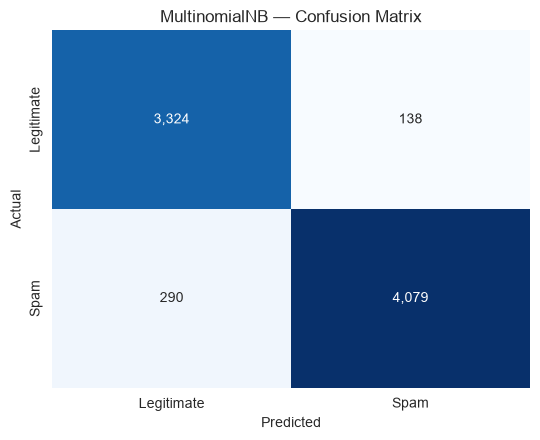

In [17]:
nb_pred = nb_pipe.predict(X_test)

print(classification_report(y_test, nb_pred,
                            target_names=["Legitimate (0)", "Spam/Phishing (1)"]))

cm = confusion_matrix(y_test, nb_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Legitimate", "Spam"], yticklabels=["Legitimate", "Spam"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("MultinomialNB — Confusion Matrix")
plt.tight_layout()
plt.show()

### 7.4 Underfitting check — train vs test vs cross-validation

In [18]:
baseline = pd.DataFrame(results).set_index("model")
baseline["train_test_gap"] = baseline["train_acc"] - baseline["test_acc"]

baseline.round(4)

,train_acc,test_acc,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std,train_test_gap
model,,,,,,,,,
Dummy (majority class),0.5578,0.5579,0.2790,0.5000,0.3581,0.5000,0.3581,0.0000,-0.0001
MultinomialNB (baseline),0.9492,0.9453,0.9435,0.9469,0.9448,0.9878,0.9491,0.0022,0.0038


### 7.5 Score to beat

In [19]:
BASELINE_F1 = nb_row["f1"]
BASELINE_ACC = nb_row["test_acc"]

print(f"Baseline macro F1 : {BASELINE_F1:.4f}")
print(f"Baseline accuracy : {BASELINE_ACC:.4f}")
print(f"Majority-class floor: {dummy_row['test_acc']:.4f}")

Baseline macro F1 : 0.9448
Baseline accuracy : 0.9453
Majority-class floor: 0.5579


## Part 8 — Machine Learning Model Development

### 8.1 Model 1

### 8.2 Model 2

### 8.3 Model 3

### 8.4 Model 4

### 8.5 Model comparison table

## Part 9 — Model Evaluation

### 9.1 Metrics for every model

### 9.2 Confusion matrices

### 9.3 ROC and Precision-Recall curves

### 9.4 Comparison table

## Part 10 — Overfitting and Underfitting Analysis

### 10.1 Train vs validation performance

### 10.2 Learning curves

### 10.3 Diagnosis per model

## Part 11 — Hyperparameter Experiments

### 11.1 Experiment 1

### 11.2 Experiment 2

### 11.3 Experiment 3

### 11.4 Summary

## Part 12 — Model Comparison and Selection

### 12.1 Final comparison table

### 12.2 Final model selection

### 12.3 Held-out test set evaluation

## Part 13 — Error Analysis

### 13.1 Confusion matrix of the final model

### 13.2 False positives

### 13.3 False negatives

### 13.4 Error patterns